
# Quickstart — `opciones.precios` y `opciones.griegas`

Las clases (`OpcionEuropea`, `OpcionForex`, etc.) ya se cubren en los
scripts `ej_op_*.py`. Este notebook se concentra en las **funciones
sueltas** que hay debajo de esas clases — útil si quieres entender qué
hace cada clase por dentro, o si prefieres trabajar sin instanciar un
objeto.

Usamos los mismos datos que ya aparecen en `ej_op_Europeas.py`,
`ej_op_Americanas_Div.py`, `ej_op_Futuros.py` y `ej_op_Divisas.py`, para
que se lea como "esto es lo que hay detrás" de esos ejemplos.


In [35]:

from opciones.precios import(
    Black_Scholes,
    d1_d2,
    ajuste_s0,

    Black_76,

    Black_Scholes_Fx,
    Fx_d1_d2,

    Aproximacion_Black,

    ArbolBinomial_crr,
    graficar_arbol_bin
)

from opciones.griegas import(
    Delta,
    Gamma,
    Theta,
    Vega,
    Rho,

    Delta_A_div,
    Gamma_A_div,
    Theta_A_div,
    Vega_A_div,
    Rho_A_div,

    Delta_B76,
    Gamma_B76,
    Theta_B76,
    Vega_B76,
    Rho_B76,

)

import numpy as np



## `opciones.precios`

### `d1_d2` + `Black_Scholes` — opción europea estándar


In [2]:

s0, k, r, t, sigma = 80, 80, 0.10, 6/12, 0.2

d1, d2 = d1_d2(s0, k, r, t, sigma)
d1, d2


(np.float64(0.42426406871192845), np.float64(0.2828427124746189))

In [5]:

Black_Scholes(s0, k, t, r, sigma, 'call'),Black_Scholes(s0, k, t, r, sigma, 'put')


(np.float64(6.622243167556448), np.float64(2.7205971276135656))


### `ajuste_s0` — llevar dividendos discretos a un solo `s0` efectivo

`ajuste_s0` resta el valor presente de los dividendos a `s0`; ese valor ya
ajustado se puede meter directo a `Black_Scholes` para obtener el precio
de una europea con dividendos, sin necesidad de `OpcionEuropeaDiv`.


In [6]:

dividendos   = [0.2, 0.3, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
t_dividendos = [1/12, 2/12, 3/12, 4/12, 5/12, 6/12, 7/12, 8/12, 9/12]

s0_ajustado = ajuste_s0(s0, r, t, dividendos, t_dividendos)
s0_ajustado


np.float64(77.77680650826944)

In [7]:

Black_Scholes(s0_ajustado, k, t, r, sigma, 'call')   # == OpcionEuropeaDiv(...).precio('call')


np.float64(5.227767436086637)


### `Black_76` — opciones sobre futuros


In [8]:

f0, k2, t2, r2, sigma2 = 100, 105, 1, 0.05, 0.2

Black_76(f0, k2, t2, r2, sigma2, 'call'), Black_76(f0, k2, t2, r2, sigma2, 'put')


(np.float64(5.617574279282911), np.float64(10.373721401786474))


### `Fx_d1_d2` + `Black_Scholes_Fx` — opciones sobre divisas (Garman-Kohlhagen)


In [9]:

s0_fx, k_fx, t_fx, sigma_fx, rd, rf = 1.1, 1.1, 3/12, 0.10, 0.05, 0.03

d1_fx, d2_fx = Fx_d1_d2(s0_fx, k_fx, t_fx, sigma_fx, rd, rf)
d1_fx, d2_fx


(np.float64(0.12500000000000003), np.float64(0.07500000000000002))

In [10]:

Black_Scholes_Fx(s0_fx, k_fx, t_fx, sigma_fx, rd, rf, 'call'), Black_Scholes_Fx(s0_fx, k_fx, t_fx, sigma_fx, rd, rf, 'put')


(np.float64(0.024552438942584298), np.float64(0.019107159184801825))


### `Aproximacion_Black` — call americana con dividendos, aproximación cerrada

Evalúa mantener hasta `T` vs. ejercer justo antes de cada dividendo, y
toma el máximo — es la aproximación que usa `OpcionAmericanaDiv` cuando
`tipo='call'`.


In [11]:

Aproximacion_Black(s0, k, t, r, sigma, dividendos, t_dividendos)


np.float64(5.227767436086637)


### `ArbolBinomial_crr` — árbol binomial (call o put, europea o americana)

A diferencia de `Aproximacion_Black`, el árbol sí puede valuar **puts**
americanos (que no tienen aproximación cerrada) y sirve como
comprobación cruzada del resultado de `Aproximacion_Black` para calls.


### `graficar_arbol_bin` — visualización del árbol (función propia de la librería)


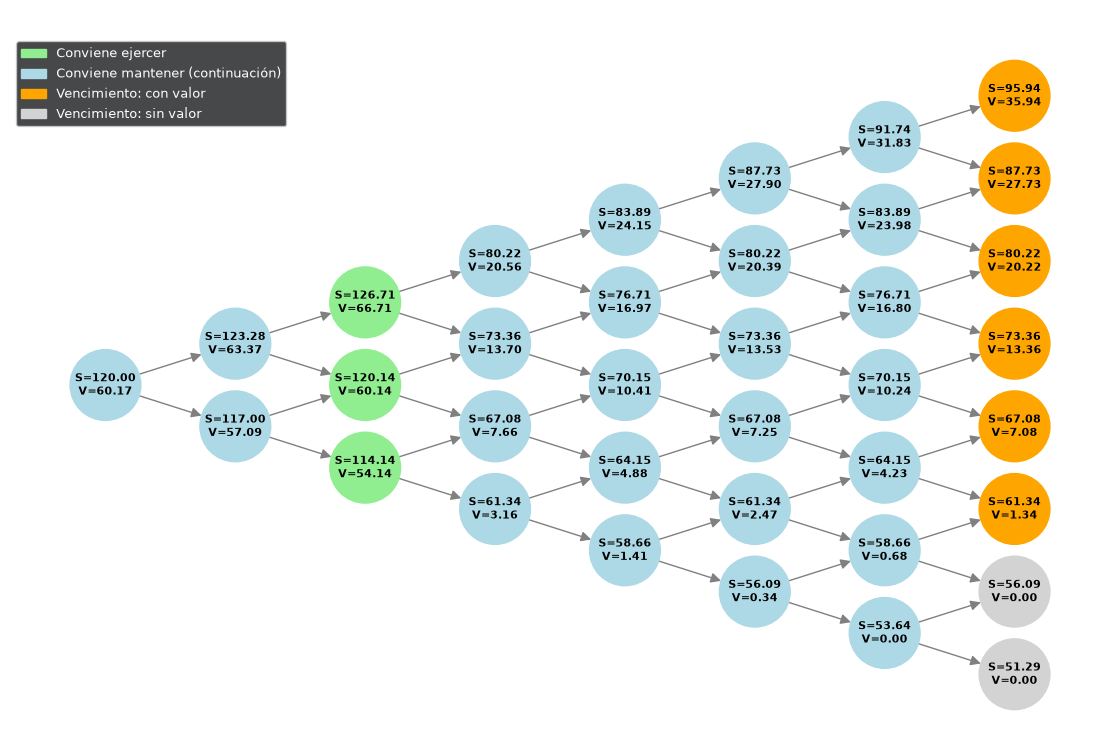

In [51]:
s0, k, r, t, sigma = 120, 60, 0.01, 1.0, 0.08
dividendos   = [50]
t_dividendos = [0.30]
n = 7

S,V=ArbolBinomial_crr(s0, k, r, t, n, u, d, tipo='call', es_americana=True,
                      dividendo=dividendos, t_dividendo=t_dividendos)

graficar_arbol_bin(S, V, k, tipo='call', es_americana=True)



---
## `opciones.griegas`

### Black-Scholes estándar — `Delta`, `Gamma`, `Theta`, `Vega`, `Rho`

Reutilizamos `d1`, `d2` calculados arriba con `d1_d2`.


In [13]:

Delta(s0, k, t, r, sigma, tipo='call')


np.float64(0.6643133797295637)

In [19]:

Gamma(s0, sigma, t, d1)


np.float64(0.0322269034255926)

In [18]:
Theta(s0, k, t, r, sigma, d1, d2, tipo='call')


np.float64(-8.777326359556717)

In [20]:

Vega(s0, t, sigma, d1)


np.float64(20.625218192379265)

In [21]:

Rho(k, t, r, d2, tipo='call')


np.float64(23.261413605404325)


### Americana con dividendos (diferencias finitas) — `_A_div`

Estas no requieren `d1`/`d2`: cada función perturba internamente el
parámetro correspondiente y revalúa con el árbol/aproximación.


In [26]:

Delta_A_div(s0, k, t, r, sigma, dividendos, t_dividendos, tipo='Call')


np.float64(0.5888761185212887)

In [19]:

Gamma_A_div(s0, k, t, r, sigma, dividendos, t_dividendos, tipo='Call')


np.float64(0.03535071932975197)

In [23]:

Theta_A_div(s0, k, t, r, sigma, dividendos, t_dividendos, tipo='Call')   # (theta anualizada, theta diaria)


(np.float64(-8.475091272437254), np.float64(-0.033631314573163706))

In [24]:

Vega_A_div(s0, k, t, r, sigma, dividendos, t_dividendos, tipo='Call')


np.float64(21.392115552758995)

In [25]:

Rho_A_div(s0, k, t, r, sigma, dividendos, t_dividendos, tipo='Call')


np.float64(20.734975205982664)


### Black-76 (futuros) — `_B76`

Reutilizamos `f0`, `k2`, `t2`, `r2`, `sigma2` de la sección de `Black_76`.


In [27]:

d1_76 = d1_d2(f0, k2, 0, t2, sigma2)[0]   # en Black-76, d1 no depende de r; se calcula con "r=0" en la formula de d1_d2
d1_76


np.float64(-0.14395082084716024)

In [28]:

Delta_B76(r2, t2, d1_76, tipo='call')


np.float64(0.4211755214150778)

In [29]:

Gamma_B76(f0, r2, t2, sigma2, d1_76)


np.float64(0.018778705708824703)

In [30]:

Theta_B76(f0, k2, t2, r2, sigma2, d1_76, tipo='call')


np.float64(-3.4748624278007956)

In [31]:

Vega_B76(f0, r2, t2, d1_76)


np.float64(37.55741141764941)

In [32]:

precio_call_futuro = Black_76(f0, k2, t2, r2, sigma2, 'call')
Rho_B76(t2, precio_call_futuro)   # usa el precio ya calculado, no d1/d2


np.float64(-5.617574279282911)